# Lab 3 - Making a SkewT from scratch

In [74]:
#import statements
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as ticker
#import metpy.calc as mpcalc
#from metpy.cbook import get_test_data

In [114]:
#defining constants
epsilon = 0.622  # Ratio of the gas constants for dry air and water vapor
R_d = 287.05  # Gas constant for dry air (J/(kg·K))
R_v = 461.5  # Gas constant for water vapor (J/(kg·K))
c_pd = 1005.7  # Specific heat capacity of dry air at constant pressure (J/(kg·K))
L_v = 2.5e6  # Latent heat of vaporization (J/kg)
g = 9.81  # Gravitational acceleration (m/s^2)

#defining helper functions for skewt
def e_s(temperature): #calculate the saturation vapor pressure over liquid water (in hPa) using the Bolton formula.
    return 6.112 * np.exp((17.67 * temperature) / (temperature + 243.5))

def r_s(temperature, pressure): #calculate the saturation mixing ratio (in kg/kg) using the saturation vapor pressure and pressure.
    return epsilon * e_s(temperature) / (pressure - e_s(temperature))

def moist_adiabatic_lapse_rate(temperature, pressure): #calculate the moist adiabatic lapse rate (in K/m) using the temperature and pressure.
    r_s_value = r_s(temperature, pressure)
    numerator = 1 + (L_v*r_s_value)/(R_d*temperature)
    denomenator = 1 + (L_v**2*r_s)/(c_pd*R_v*temperature**2)
    return (g/c_pd) * numerator / denomenator

def dry_adiabatic_lapse_rate(temperature, pressure): #calculate the dry adiabatic lapse rate (in K/m) using the temperature.
    return (R_d * temperature / (c_pd * pressure))



In [115]:
#skewing the temperature profile for skew-T log-P diagram
def skewT(temperature, pressure, skew=-20, ):
    """
    Skew the temperature axis for a Skew-T log-P plot.

    Parameters
    ----------
    temperature : array-like
        Temperature values in degrees Celsius.
    pressure : array-like
        Pressure values in hPa.
    skew : float, optional
        Amount of skewing, by default -20.
    """
    return temperature + skew * np.log(pressure / 1000.0)

def plot_skewT(temperature, pressure, dewpoint=None, wind=None):
    """
    Plot a Skew-T log-P diagram.

    Parameters
    ----------
    temperature : array-like
        Temperature values in degrees Celsius.
    pressure : array-like
        Pressure values in hPa.
    dewpoint : array-like, optional
        Dewpoint temperature values in degrees Celsius, by default None.
    wind : array-like, optional
        Wind speed and direction values, by default None.
    """
    fig, ax = plt.subplots(figsize=(9, 9))
    
    # Skew the temperature profile
    skewed_temp = skewT(temperature, pressure)
    
    # Plot temperature profile
    ax.plot(skewed_temp, pressure, color='red', label='Temperature')
    
    # Plot dewpoint profile if provided
    if dewpoint is not None:
        skewed_dewpoint = skewT(dewpoint, pressure)
        ax.plot(skewed_dewpoint, pressure, color='green', label='Dewpoint')

    #plot moist adiabats
    ax.plot(moist_adiabatic_lapse_rate(temperature, pressure), pressure, color='blue', label='Moist Adiabats')

    #plot dry adiabats
    #moist_adiabats = moist_adiabatic_lapse_rate(temperature, pressure)
    #for idx in range(len(moist_adiabats)):
    #    ax.plot(moist_adiabats[idx], pressure[idx], color='blue', linestyle='--', linewidth=0.5)

    #plot dry adiabats
    dry_adiabats = dry_adiabatic_lapse_rate(temperature, pressure)
    #for idx in range(len(dry_adiabats)):
    #    ax.plot(dry_adiabats[idx], pressure[idx], color='orange', linestyle='--', linewidth=0.5)

    ax.plot(dry_adiabats, pressure, color='orange', label='Dry Adiabats')

    #plotting isotherms
    isotherms = np.arange(-80, 50, 10)
    for temp in isotherms:
        skewed_isotherm = skewT(np.full_like(pressure, temp), pressure)
        ax.plot(skewed_isotherm, pressure, color='gray', linewidth=0.5)
    
    # Set y-axis to log scale and invert it
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.yaxis.set_major_formatter('{x:.0f}')
    ax.yaxis.set_minor_formatter('{x:.0f}')
    ax.grid(which='minor', axis='y', color='gray')


    #Setting x-axis limits
    ax.set_xlim(-40, 50)

    #setting y-axis limits
    ax.set_ylim(1000, 100)
    
    # Set labels and title
    ax.set_xlabel('Temperature (°C)')
    ax.set_ylabel('Pressure (hPa)')
    ax.set_title('Skew-T log-P Diagram')
    
    
    plt.show()

In [ ]:
#getting test data for SkewT using data from the wyoming upper air site (ADD SPECIFIC TIME, DATE, AND LOCATION)
test_data = pd.read_csv('data/2026092400-72357.csv') #reading in the csv file generated from the site


In [109]:
test_data

,time,longitude,latitude,pressure_hPa,geopotential height_m,temperature_C,dew point temperature_C,ice point temperature_C,relative humidity_%,humidity wrt ice_%,mixing ratio_g/kg,wind direction_degree,wind speed_m/s
0,2026-09-23 23:04:53,-97.4379,35.1810,977.5,345,32.7,17.4,17.4,40,40,12.88,100,4.6
1,2026-09-23 23:04:54,-97.4380,35.1811,976.8,351,32.1,16.9,16.9,40,40,12.48,112,4.6
2,2026-09-23 23:04:55,-97.4381,35.1812,976.5,354,32.0,16.9,16.9,40,40,12.47,116,4.8
3,2026-09-23 23:04:56,-97.4381,35.1813,976.2,357,32.0,16.9,16.9,40,40,12.46,117,5.0
4,2026-09-23 23:04:57,-97.4382,35.1813,975.9,359,31.9,16.8,16.8,41,41,12.44,116,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4137,2026-09-24 00:49:49,-97.1252,35.2423,6.6,34090,-40.4,-81.5,-76.8,1,1,0.09,302,13.4
4138,2026-09-24 00:50:06,-97.1231,35.2409,6.5,34192,-40.5,-81.6,-76.8,1,1,0.09,312,15.3
4139,2026-09-24 00:50:22,-97.1211,35.2393,6.4,34295,-40.3,-81.5,-76.7,1,1,0.09,319,16.1
4140,2026-09-24 00:50:40,-97.1191,35.2372,6.3,34399,-40.8,-81.8,-77.0,1,1,0.09,328,15.2


In [116]:
moist_ad = moist_adiabatic_lapse_rate(test_data.temperature_C, test_data.pressure_hPa)
plt.plot(moist_ad)

TypeError: unsupported operand type(s) for *: 'float' and 'function'

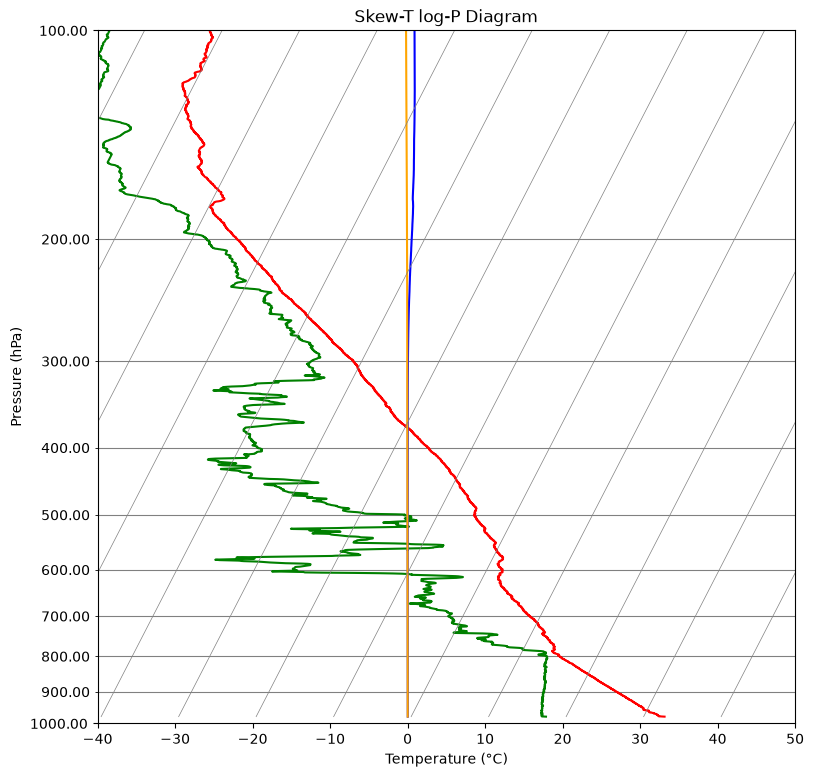

In [108]:
plot_skewT(test_data.temperature_C, test_data.pressure_hPa, dewpoint=test_data['dew point temperature_C'])

## Written answers

1) Why does the moist adiabatic lapse rate, $\Gamma_m=-\frac{dT}{dz}$, generally increase as a saturated parcel
ascends and cools?

2. At a fixed pressure, how and why does $\Gamma_m$ differ between warmer and colder moist adiabats?

3. Break” your SkewT: test a wide range of skew values and describe what happens to the plot. What
does this test teach you about the value of skewing? No need to show your tests; just describe your
interpretations.

4. Describe two features of the sounding you chose to plot that you find particularly interesting or useful.
Refer to specific pressure levels or layers and explain the physical significance of each feature.

5. What was the most challenging step for this lab? How did you navigate it, and what was the solution?
If you leaned on GenAI tools, how did they contribute to your work and how did you check the
information they provided?